In [1]:
import sys
sys.path.append('/home/potzschf/repos/')
from helperToolz.helpsters import *
from helperToolz.dicts_and_lists import *

/tmp/ipykernel_3941759/652076445.py:10: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(min(df_m['Loss']), max(df_m['Loss']))


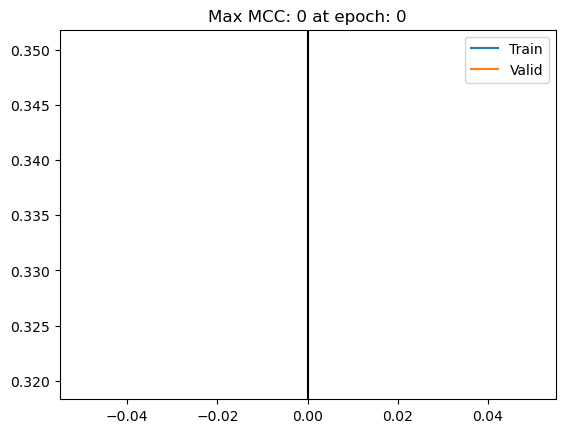

In [2]:
model_name = 'AI4_RGB_exclude_True'
model_name = 'Fine_tuner_on_AI4_RGB_exclude_True_38'
##### Create a figure
# load data
df = pd.read_csv(f'/data/Aldhani/eoagritwin/fields/output/loss/loss_{model_name}.csv', sep=',')
df_m = df.groupby(['Epoch', 'Mode']).mean().reset_index()

plt.plot(df_m.loc[df_m['Mode'] == 'Train', 'Epoch'], df_m.loc[df_m['Mode'] == 'Train', 'Loss'], label='Train')
plt.plot(df_m.loc[df_m['Mode'] == 'Valid', 'Epoch'], df_m.loc[df_m['Mode'] == 'Valid', 'Loss'], label='Valid')
plt.ylim(min(df_m['Loss']), max(df_m['Loss']))

# mcc
df2 = pd.read_csv(f'/data/Aldhani/eoagritwin/fields/output/loss/MCC_{model_name}.csv', sep=',')
maxMCC = df2['MCC'].max()
df2[df2['MCC']==df2['MCC'].max()]
emaxMCC = df2.loc[df2['MCC'].idxmax(), 'Epoch']

plt.title('Max MCC: ' + str(round(maxMCC, 2)) + ' at epoch: ' + str(emaxMCC))
plt.vlines(x=emaxMCC, ymin=0, ymax=.5, colors='black')
plt.legend(loc='upper right')



In [3]:
df

,Epoch,Iteration,Loss,Mode
0,0,0,NaN,Train
1,0,1,NaN,Train
2,0,2,NaN,Train
3,0,3,NaN,Train
4,0,4,NaN,Train
...,...,...,...,...
236545,49,1178,NaN,Valid
236546,49,1179,NaN,Valid
236547,49,1180,NaN,Valid
236548,49,1181,NaN,Valid


In [ ]:
# define the model (.pth) and assess loss curves
model_name = dataFolder + 'output/models/model_state_All_but_LU_transformed_42.pth'
model_name_short = model_name.split('/')[-1].split('.')[0]
local_rank = 0
# torch.cuda.set_device(local_rank)
# torch.manual_seed(0)

NClasses = 1
nf = 96
verbose = True
model_config = {'in_channels': 4,
                'spatial_size_init': (128, 128),
                'depths': [2, 2, 5, 2],
                'nfilters_init': nf,
                'nheads_start': nf // 4,
                'NClasses': NClasses,
                'verbose': verbose,
                'segm_act': 'sigmoid'}

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    modeli = ptavit3d_dn(**model_config).to(device)
    modeli.load_state_dict(torch.load(model_name))
    model = modeli.to(device) # Set model to gpu
    model.eval()
    
# else:
#     torch.set_num_threads(40)
#     model = ptavit3d_dn(**model_config).to(device)
#     model.load_state_dict(torch.load(model_name, map_location=torch.device("cpu")))  
#     model.eval()


vdata = RocksDBDataset(dataFolder + 'output/rocks_db/FORCE.db/train.db', transform=TrainingTransform_for_rocks_Valid)

#vdata = VALIDataset()
preds = []

valid_loader = DataLoader(dataset=vdata, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

trg =  sorted(glob.glob(os.path.join(dataFolder + 'ai4boundaries/sentinel2/masks/' + 'LU' + '/*.tif')))

for i, (image, label) in enumerate(valid_loader):
    print(image.shape)
    print(type(image))
    
    if torch.cuda.is_available():
        with torch.no_grad():
            pred = model(image.cuda())
            preds.append(pred.detach().cpu().numpy())
    else:
        image = image.to(device)  # Move image to the correct device
        with torch.no_grad():
            pred = model(image)
            preds.append(pred.detach().cpu().numpy())

    # # store the prediction
    # outDir = dataFolder + 'output/predictions/' + model_name_short + '_with_LU_rocks'
    # os.makedirs(outDir, exist_ok=True)
    # export_np_to_tif(preds[i][0,:,:,:], rasterio.open(trg[i]), outDir, '/' + model_name_short + '_pred_LU_' + trg[i].split('/')[-1].split('_')[1])

    # # store the classified prediction
    # classified = InstSegm(preds[i][0,0,:,:], preds[i][0,1,:,:],0.4,0.2)
    # export_single_np_to_tif(classified,
    #                  rasterio.open(trg[i]),
    #                  outDir, '/' + model_name_short + '_pred_LU_' + trg[i].split('/')[-1].split('_')[1] + '_classified')



 @@@@@@@@@@@@@ Going DOWN @@@@@@@@@@@@@@@@@@@ 
depth:= 0, layer_dim_in: 96, layer_dim: 96, stage_depth::2, spatial_size::(32, 32), scales::[16, 8, 8]
depth:= 1, layer_dim_in: 96, layer_dim: 192, stage_depth::2, spatial_size::(16, 16), scales::[32, 4, 4]
depth:= 2, layer_dim_in: 192, layer_dim: 384, stage_depth::5, spatial_size::(8, 8), scales::[64, 2, 2]
depth:= 3, layer_dim_in: 384, layer_dim: 768, stage_depth::2, spatial_size::(4, 4), scales::[128, 1, 1]
 XXXXXXXXXXXXXXXXXXXXX Coming up XXXXXXXXXXXXXXXXXXXXXXXXX 
depth:= 4, layer_dim_in: 384, layer_dim: 384, stage_depth::5, spatial_size::(8, 8), scales::[64, 2, 2]
depth:= 5, layer_dim_in: 192, layer_dim: 192, stage_depth::2, spatial_size::(16, 16), scales::[32, 4, 4]
depth:= 6, layer_dim_in: 96, layer_dim: 96, stage_depth::2, spatial_size::(32, 32), scales::[16, 8, 8]


ValueError: cannot reshape array of size 49152 into shape (4,6,128,128)

ValueError: cannot reshape array of size 49152 into shape (4,6,128,128)

In [ ]:
preds = []
data_cube = np.transpose(cube, (2, 0, 1))
reshaped_cube = data_cube.reshape(4, 6, 3000, 6000)
reshaped_cube = reshaped_cube[:,:,:256,:256]
image = torch.tensor(reshaped_cube[np.newaxis, ...])
image = image.to(torch.float)
image = image.to(device)
#print(image.dtype)
# for param in model.parameters():
#     print(param.dtype)
#     break
with torch.no_grad():
    pred = model(image)
    preds.append(pred.detach().cpu().numpy())

In [ ]:
torch.cuda.empty_cache()